# Calling malignant cells from the inferCNV residuals - `newcnv`

Second, independent version of the 05_1 decision step. `call_malignant.ipynb` is **not**
modified and its outputs are **not** overwritten: everything this notebook writes carries the
`newcnv` tag, so the two calls sit side by side on disk and can be compared.

Both read the same per-cell tables (`$DATA_DIR/05_tum/summary/*_cnv.csv`). inferCNV is **not**
re-run - nothing below needs it.

## What changes, and why

The original call is a per-cell threshold: an epithelial cell is malignant when it is above
the 95th percentile of its own cohort's stromal null on *both* axes. Three things are wrong
with it, and all three were measured rather than suspected.

**1. The verdict is taken at the wrong level.** Shiao et al. take it per epithelial
*subcluster* - median statistic across the cells of a cluster, then a z-score across clusters
(STAR Methods, "Classification of malignant versus normal epithelial cells"). The i6 HMM is
only how they produce the per-cell statistic that gets averaged; the robustness comes from the
averaging, not from the HMM. A median over thousands of cells is stable where a per-cell
threshold is not. We already have a per-cell statistic and, in `04_epi/shiao_epi.h5ad`, an
epithelial leiden clustering computed from expression and independent of the CNV residuals.
That is Shiao's setup, minus the HMM.

Measured: 11,271 epithelial cells sit in clusters that are unambiguously aneuploid at the
median and patient-private, but fall below the per-cell threshold on one axis. The per-cell
rule discards them.

**2. Some cohorts have no detectable tumour and are called anyway.** Comparing, per cohort,
the epithelial crossing rate against that cohort's *stromal* crossing rate splits the dataset
cleanly: seven cohorts sit at 4.0-6.2% epithelial - the rate the null produces on itself -
against 11.6-95% for everyone else. Six are dropped downstream by `MIN_CELLS_PER_COHORT`, but
Patient52 is not: 9,243 epithelial cells, 385 called malignant, and it enters the `tum` subset
as one of the 19 cohorts DRVI has to estimate batch parameters for.

**3. The stromal null is used as one block.** It contains three different populations -
fibroblasts, endothelium, perivascular - and which one dominates a cohort's null changes the
call in a handful of cohorts (Patient10: 3.6% malignant off the fibroblast null, 48.8% off
the endothelial one). The operating cut still uses the whole block, which is the
highest-power estimate, but the three are now computed separately and reported, so a cohort
whose null is unstable is visible instead of silent.

## What does not change

Per-patient runs, the immune reference (T/NK + myeloid), B/plasma excluded from every run, the
two continuous axes, the per-cohort stromal null, no HMM. The reference composition is the one
axis where this stays deliberately further from Shiao than it could: they use every
non-epithelial type as reference, we keep fibroblasts, endothelium and perivascular cells out
of it as an internal negative control, because a control that has been folded into the
reference can no longer detect anything.

## Packages and paths

In [1]:
from __future__ import annotations

import anndata as ad
import pandas as pd
import numpy as np
import os
import glob

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['figure.facecolor'] = 'white'

try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    SCRIPT_DIR = os.getcwd()
PHASE_DIR = os.path.dirname(SCRIPT_DIR)      # 05_drvi_tumoral_epi/

TAG = 'newcnv'                               # every output of this notebook carries it

FIG_DIR = os.path.join(PHASE_DIR, 'figures', '05_1_infercnv', TAG)
TABLE_DIR = os.path.join(PHASE_DIR, 'tables', '05_1_infercnv', TAG)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

print('FIG_DIR  :', FIG_DIR)
print('TABLE_DIR:', TABLE_DIR)

FIG_DIR  : /home/albertoc/Desktop/QCB-Master-Thesis/05_drvi_tumoral_epi/figures/05_1_infercnv/newcnv
TABLE_DIR: /home/albertoc/Desktop/QCB-Master-Thesis/05_drvi_tumoral_epi/tables/05_1_infercnv/newcnv


In [ ]:
DATA_DIR = os.environ.get('DATA_DIR', '').strip() or os.path.join(os.path.dirname(PHASE_DIR), 'datasets')
DATA_DIR = os.path.abspath(os.path.expanduser(DATA_DIR))
CNV_DIR = os.path.join(DATA_DIR, '05_tum')
SUMMARY_DIR = os.path.join(CNV_DIR, 'summary')

SHIAO_H5AD = os.path.join(DATA_DIR, 'shiao.h5ad')                 # .obs only, backed
STATUS_OUT = os.path.join(CNV_DIR, f'cnv_status_{TAG}.csv')       # what this notebook writes
STATUS_OLD = os.path.join(CNV_DIR, 'cnv_status.csv')              # the existing call, read-only

GROUP_EPI = 'epi'
GROUP_STROMAL = 'stromal'
GROUP_HELDOUT = 'immune_heldout'
REF_GROUPS = ('ref_tcell', 'ref_myeloid')
GROUP_COLORS = {'epi': '#2f7d4f', 'stromal': '#d19a34', 'immune_heldout': '#7ba05b',
                'ref_tcell': '#5f7fb0', 'ref_myeloid': '#8d6ca8'}

# The stromal block, split. Same labels as prepare_infercnv_input.py's STROMAL_STRATA.
# Note that the block is now SAMPLED stratified over these three, so its composition is
# balanced by construction and this split is a robustness check rather than a correction.
FIBRO = {'Fibro-SFRP4', 'Fibro-major', 'Fibro-matrix', 'Fibro-prematrix'}
ENDO = {'Lymph-immune', 'Lymph-major', 'Lymph-valve1', 'Lymph-valve2',
        'Vas-arterial', 'Vas-capillary', 'Vas-venous'}
PVL = {'pericytes', 'vsmc'}
assert not (FIBRO & ENDO) and not (FIBRO & PVL) and not (ENDO & PVL)

print('output  :', STATUS_OUT)
print('subclusters read from the summaries themselves (no phase-04 dependency)')


## The parameters

Six numbers, all in one cell. `Q` and `MIN_NULL` are carried over from `call_malignant.ipynb`
unchanged; the other four are new and each is set where the data has a gap, not at a round
number chosen in advance - the cells below print the distribution each one cuts.

In [ ]:
Q = 0.95            # quantile of the cohort's stromal null that defines the per-cell rule
MIN_NULL = 30       # a cohort with fewer stromal cells cannot define its own null

MAL_MED = 0.90      # a subcluster whose MEDIAN cell sits above this on the null -> malignant
NORM_MED = 0.75     # ...below this -> normal. In between -> borderline.
MIN_SUB = 20        # a subcluster smaller than this gets no verdict of its own: its median
                    # is not an aggregate of anything, so its cells fall back to the
                    # per-cell rule and are flagged. At the operating resolution of 0.005
                    # this is ~2% of the epithelium (see sensitivity_resolution.py).
GATE_FRAC = 0.10    # a cohort needs at least this fraction of its epithelium above the null,
                    # on EITHER readout, to be considered to contain detectable tumour

REQUIRE_CELL_RULE = False
# False (default) = the subcluster verdict decides, the per-cell rule is recorded next to it
#   as corroboration. A cell in a malignant subcluster is malignant.
# True = the conservative conjunction: a cell must ALSO pass the per-cell rule. The
#   `cell_rule` column is written either way, so this can be re-decided downstream without
#   re-running anything.


## The per-cell tables

In [4]:
paths = sorted(glob.glob(os.path.join(SUMMARY_DIR, '*_cnv.csv')))
assert paths, f'no summaries in {SUMMARY_DIR}: run ./infercnv_all.sh first'
cnv = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
print(f'{len(paths)} cohort(s), {len(cnv):,} cells')

census = pd.read_csv(os.path.join(CNV_DIR, 'cohort_census.csv'))
prepared = set(census.loc[census['status'] == 'prepared', 'cohort'])
ran = set(cnv['cohort'].unique())
print(f'prepared: {len(prepared)} | with a summary: {len(ran)}')
missing = sorted(prepared - ran)
if missing:
    print('PREPARED BUT NO SUMMARY (inferCNV failed on these):', missing)

cnv.groupby('group', observed=True).size()

33 cohort(s), 165,054 cells
prepared: 32 | with a summary: 33


group
epi            75438
ref_myeloid    31114
ref_tcell      32928
stromal        25574
dtype: int64

In [5]:
# cell_type comes along for the fibro / endo / PVL split of the stromal null. Read backed:
# only .obs is touched and shiao.h5ad is never modified.
_obs = ad.read_h5ad(SHIAO_H5AD, backed='r').obs[['cohort', 'cell_type']]
cnv = cnv.set_index('cell').join(_obs[['cell_type']]).reset_index()
assert cnv['cell_type'].notna().all(), 'a cell in a summary is not in shiao.h5ad'

cnv['stromal_sub'] = np.select(
    [cnv['cell_type'].isin(FIBRO), cnv['cell_type'].isin(ENDO), cnv['cell_type'].isin(PVL)],
    ['fibro', 'endo', 'pvl'], default='')          # np.select on strings: '' not None
cnv.loc[cnv['group'] != GROUP_STROMAL, 'stromal_sub'] = ''

cnv[cnv['group'] == GROUP_STROMAL].groupby('stromal_sub', observed=True)['cnv_score'].agg(['size', 'median']).round(5)

,size,median
stromal_sub,,
endo,8976,0.00083
fibro,12571,0.00090
pvl,4027,0.00097


## Step 1 - where each cell sits on its own cohort's null

One statistic replaces the two thresholds. For every cell, `p_score` is the fraction of that
cohort's stromal cells it exceeds on `cnv_score`, `p_corr` the same on `cnv_corr`, and

```
nullpos = min(p_score, p_corr)
```

is its position on the *worse* of the two axes. `nullpos > Q` is then **exactly** the rule
`call_malignant.ipynb` applies - identical calls, one number instead of two comparisons - and
the same number is what gets aggregated per cluster in step 3. That is the whole point of
defining it this way: the per-cell rule and the cluster rule read the same quantity, so a
disagreement between them is informative rather than an artefact of two different scales.

It is also already normalised per cohort, which is what makes cross-patient aggregation legal
at all. Raw `cnv_score` is not comparable between runs - the phase README is explicit about
this - so a z-score taken across clusters that pool several patients, the way Shiao's is,
would be reading the between-cohort shift. Shiao can do it because the HMM's "% of genes
altered" is a discretised quantity comparable across runs; a continuous residual is not.

In [6]:
stromal = cnv[cnv['group'] == GROUP_STROMAL]
n_null = stromal.groupby('cohort', observed=True).size()
usable = set(n_null[n_null >= MIN_NULL].index)
unusable = sorted(set(cnv['cohort'].unique()) - usable)
print(f'cohorts with a usable stromal null: {len(usable)}')
print(f'cohorts without one (all their cells -> not_tested): {unusable if unusable else "none"}')

parts = []
for cohort, d in cnv.groupby('cohort', observed=True):
    s = stromal[stromal['cohort'] == cohort]
    if len(s) < MIN_NULL:
        continue
    d = d.copy()
    for ax in ('cnv_score', 'cnv_corr'):
        d['p_' + ax] = np.searchsorted(np.sort(s[ax].to_numpy()), d[ax].to_numpy()) / len(s)
    parts.append(d)

a = pd.concat(parts, ignore_index=True)
a['nullpos'] = np.minimum(a['p_cnv_score'], a['p_cnv_corr'])
a['cell_rule'] = a['nullpos'] > Q
print(f'\n{len(a):,} cells on a usable null')

cohorts with a usable stromal null: 33
cohorts without one (all their cells -> not_tested): none

165,054 cells on a usable null


In [7]:
# Specificity. The reference cells are not used by the rule, so their crossing rate is a
# genuine check rather than a tautology; the stromal rate is the null's own false-positive
# rate, which is what the cohort gate in step 4 compares the epithelium against.
a.groupby('group', observed=True)['cell_rule'].agg(['size', 'sum', 'mean']).round(4)

,size,sum,mean
group,,,
epi,75438,36904,0.4892
ref_myeloid,31114,146,0.0047
ref_tcell,32928,21,0.0006
stromal,25574,189,0.0074


## Step 2 - the stromal null, split three ways

The control already contains every non-epithelial, non-immune population the dataset has -
fibroblasts, endothelium, perivascular cells - so there is nothing left to *add* to it. What
changes here is that the three are no longer only used as one block: each defines its own cut,
and the spread between the three resulting calls is a per-cohort robustness measure.

The operating cut stays the pooled one. Pooling is the highest-power estimate of the 95th
percentile under the assumption all three are diploid, and the reason to separate them is to
find out when that assumption fails in a given cohort - not to pick a smaller sample.

B and plasma cells stay out. Adding them would mean re-running inferCNV on all 33 cohorts, and
they would be a *bad* null: a clonally skewed immunoglobulin transcriptome puts structure on
chr2/chr14/chr22, which would inflate the cut in a chromosome-specific way.

In [8]:
rows = []
for cohort, d in a.groupby('cohort', observed=True):
    de = d[d['group'] == GROUP_EPI]
    r = {'cohort': cohort, 'n_epi': len(de)}
    for sub in ('fibro', 'endo', 'pvl'):
        s = d[d['stromal_sub'] == sub]
        r['n_' + sub] = len(s)
        if len(s) >= MIN_NULL and len(de):
            hit = ((de['cnv_score'] > s['cnv_score'].quantile(Q)) &
                   (de['cnv_corr'] > s['cnv_corr'].quantile(Q)))
            r['frac_' + sub] = hit.mean()
        else:
            r['frac_' + sub] = np.nan
    r['frac_pooled'] = de['cell_rule'].mean() if len(de) else np.nan
    rows.append(r)

sub_null = pd.DataFrame(rows).set_index('cohort')
sub_null['spread'] = (sub_null[['frac_fibro', 'frac_endo', 'frac_pvl']].max(axis=1)
                      - sub_null[['frac_fibro', 'frac_endo', 'frac_pvl']].min(axis=1))
sub_null['unstable_null'] = sub_null['spread'] > 0.15
sub_null.to_csv(os.path.join(TABLE_DIR, f'stromal_subnull_sensitivity_{TAG}.csv'))

print(f"cohorts whose call moves by >15 points depending on which stromal population defines "
      f"the null: {int(sub_null['unstable_null'].sum())}")
sub_null.sort_values('spread', ascending=False).round(3).head(12)

cohorts whose call moves by >15 points depending on which stromal population defines the null: 5


,n_epi,n_fibro,frac_fibro,n_endo,frac_endo,n_pvl,frac_pvl,frac_pooled,spread,unstable_null
cohort,,,,,,,,,,
Patient10,1649,537,0.036,273,0.488,153,0.286,0.062,0.452,True
Patient46,2950,721,0.601,113,0.351,166,0.357,0.520,0.250,True
Patient64,502,39,0.534,204,0.647,98,0.733,0.647,0.199,True
Patient63,7771,319,0.128,641,0.318,40,0.198,0.215,0.190,True
Patient45,2434,751,0.825,185,0.673,64,0.690,0.782,0.151,True
Patient03,234,131,0.474,180,0.372,64,0.338,0.372,0.137,False
Patient18,1148,398,0.498,412,0.368,190,0.367,0.415,0.132,False
Patient42,619,432,0.228,439,0.246,129,0.115,0.223,0.131,False
Patient43,5394,688,0.361,250,0.487,62,0.443,0.381,0.126,False


[Text(0, 0, 'Patient23'),
 Text(1, 0, 'Patient52'),
 Text(2, 0, 'Patient57'),
 Text(3, 0, 'Patient04'),
 Text(4, 0, 'Patient15'),
 Text(5, 0, 'Patient39'),
 Text(6, 0, 'Patient10'),
 Text(7, 0, 'Patient07'),
 Text(8, 0, 'Patient12'),
 Text(9, 0, 'Patient02'),
 Text(10, 0, 'Patient63'),
 Text(11, 0, 'Patient42'),
 Text(12, 0, 'Patient05'),
 Text(13, 0, 'Patient66'),
 Text(14, 0, 'Patient03'),
 Text(15, 0, 'Patient43'),
 Text(16, 0, 'Patient48'),
 Text(17, 0, 'Patient18'),
 Text(18, 0, 'Patient47'),
 Text(19, 0, 'Patient46'),
 Text(20, 0, 'Patient53'),
 Text(21, 0, 'Patient19'),
 Text(22, 0, 'Patient64'),
 Text(23, 0, 'Patient01'),
 Text(24, 0, 'Patient26'),
 Text(25, 0, 'Patient17'),
 Text(26, 0, 'Patient45'),
 Text(27, 0, 'Patient56'),
 Text(28, 0, 'Patient11'),
 Text(29, 0, 'Patient20'),
 Text(30, 0, 'Patient09'),
 Text(31, 0, 'Patient16')]

Text(0, 0.5, 'fraction of epithelium called malignant')

Text(0.5, 1.0, 'How much the call depends on which stromal population defines the null')

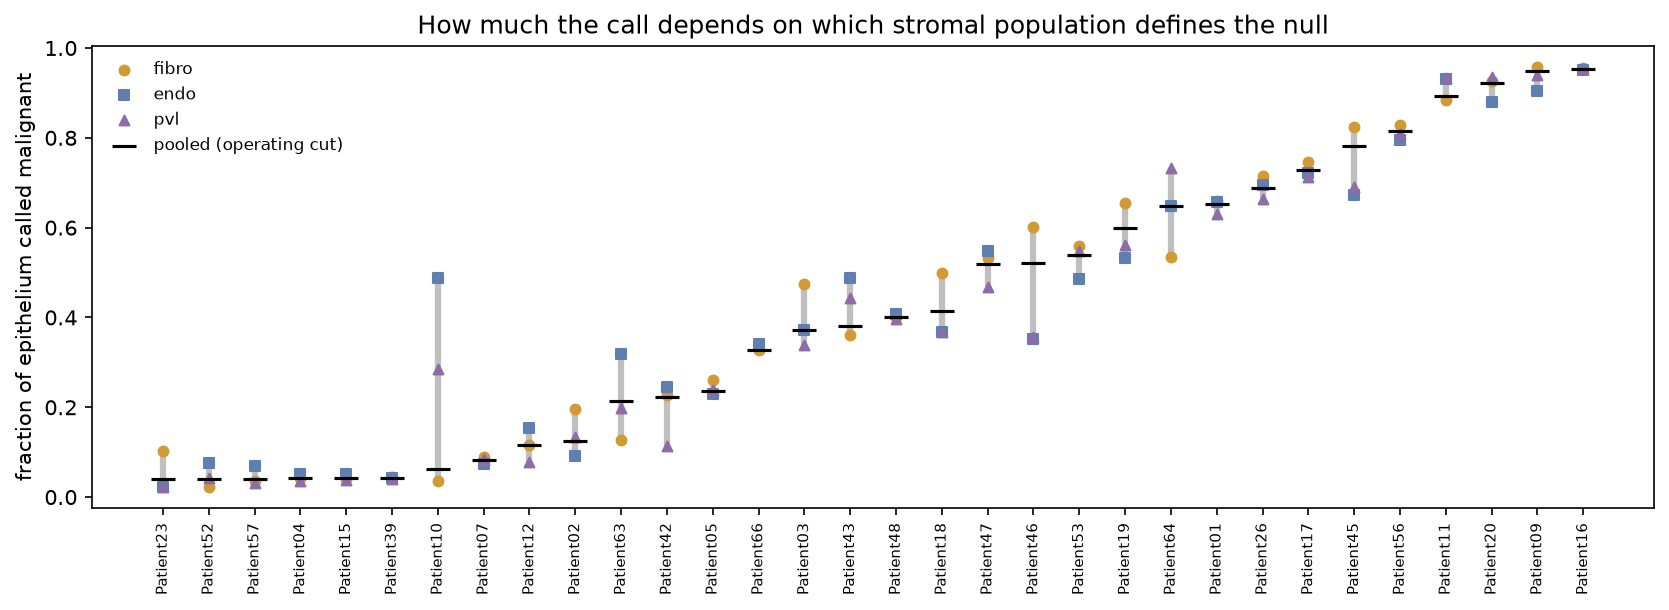

In [9]:
d = sub_null.dropna(subset=['frac_fibro', 'frac_endo']).sort_values('frac_pooled')
fig, ax = plt.subplots(figsize=(max(9, .42 * len(d)), 4.0))
x = np.arange(len(d))
ax.vlines(x, d[['frac_fibro', 'frac_endo', 'frac_pvl']].min(axis=1),
          d[['frac_fibro', 'frac_endo', 'frac_pvl']].max(axis=1), color='0.75', lw=3, zorder=1)
for sub, m, c in (('fibro', 'o', '#d19a34'), ('endo', 's', '#5f7fb0'), ('pvl', '^', '#8d6ca8')):
    ax.scatter(x, d['frac_' + sub], marker=m, s=22, color=c, label=sub, zorder=3)
ax.scatter(x, d['frac_pooled'], marker='_', s=140, color='k', label='pooled (operating cut)', zorder=4)
ax.set_xticks(x); ax.set_xticklabels(d.index, rotation=90, fontsize=7)
ax.set_ylabel('fraction of epithelium called malignant')
ax.set_title('How much the call depends on which stromal population defines the null')
ax.legend(frameon=False, fontsize=8)
fig.savefig(os.path.join(FIG_DIR, f'stromal_subnull_sensitivity_{TAG}.png'))
plt.show()

## Step 3 - the verdict, taken per epithelial subcluster

The subclusters come from **inferCNV itself**, computed inside each per-patient run
(`analysis_mode='subclusters'`, leiden at resolution 0.005 on the residual matrix). The
earlier version of this notebook borrowed `optscib_epi_leiden` from `04_epi/shiao_epi.h5ad`;
that dependency is gone, and so are the 997 epithelial cells it left without a label.

**Why the change.** 04's clustering is computed on the *integrated* object, so it mixes
patients: its cluster 0 held 16,478 cells drawn from 29 of the 33 cohorts. A copy-number
profile is private to a patient, so a cross-patient cluster cannot be a clone and the
statement "this cluster is aneuploid at the median" could not mean what it appeared to mean.
A partition computed inside one run cannot have that defect - a subcluster is a candidate
clone, and the three-clone case (two aneuploid, one not) stays separated instead of being
averaged with other patients' cells.

**The circularity, stated rather than hidden.** 04's clustering was chosen precisely because
nothing in 04 has ever seen an inferCNV output. The per-run subclusters are the opposite:
they are computed *on the residual matrix whose values are then aggregated over them*. A
partition will therefore exist, and will separate high from low, even in a patient with no
aneuploidy at all - leiden partitions noise as readily as signal. What keeps the verdict
from being circular is where the threshold comes from: the cut is a quantile of the stromal
null, and the subclustering never sees the stroma's relationship to the epithelium, nor the
reference. **The subcluster decides which cells are judged together; the null decides what
counts as high.** The cohort gate in step 4 is what stops the first half from being enough
on its own, and it is not optional here.

**On the resolution.** `sensitivity_resolution.py` sweeps 0.005 - 0.05 on four cohorts
spanning 0% to 95% tumour content: the number of subclusters grows about sevenfold and the
fraction of epithelium called CNV-positive moves by at most 0.035, with every per-patient
verdict identical throughout. What does degrade is the aggregation - at 0.05 only 23-57% of
epithelial cells sit in subclusters of 20 cells or more - which is why the operating value
is the coarse end of the range. `MIN_SUB` handles what is left.


In [ ]:
# The subclusters come from inferCNV itself, computed INSIDE each per-patient run
# (analysis_mode='subclusters', leiden at 0.005 on the residual matrix). They arrive in the
# summary tables, so there is no phase-04 object to join and no cell without a label.
assert 'subcluster' in a.columns, (
    'the summaries have no `subcluster` column: they were produced by the old '
    "analysis_mode='samples' runs. Re-run ./infercnv_all.sh")
a['subcluster'] = a['subcluster'].astype('object')
a.loc[a['group'] != GROUP_EPI, 'subcluster'] = np.nan
# Subcluster ids are per RUN: "epi_s1" exists in every cohort and denotes a different set of
# cells in each. The key is therefore (cohort, subcluster) and never the name on its own -
# grouping by the name alone would silently merge one patient's clone with another's.
a['sub_id'] = np.where(a['subcluster'].isna(), np.nan,
                       a['cohort'].astype(str) + '|' + a['subcluster'].astype(str))

epi = a[a['group'] == GROUP_EPI]
n_unlab = int(epi['subcluster'].isna().sum())
print(f'epithelial cells: {len(epi):,} | without a subcluster: {n_unlab:,}')
print(f"subclusters: {epi['sub_id'].nunique():,} over {epi['cohort'].nunique()} cohorts "
      f"(median {int(epi.groupby('sub_id', observed=True).size().median())} cells)")


In [ ]:
g = epi.dropna(subset=['sub_id']).groupby('sub_id', observed=True)
clusters = pd.DataFrame({'cohort': g['cohort'].first(), 'subcluster': g['subcluster'].first(),
                         'n': g.size(), 'median_nullpos': g['nullpos'].median(),
                         'frac_cell_rule': g['cell_rule'].mean()})
# A subcluster below MIN_SUB is not given a verdict: a median over a handful of cells is not
# the aggregate this design rests on, and calling it either way would smuggle a per-cell
# decision in under a cluster-level name.
clusters['too_small'] = clusters['n'] < MIN_SUB
clusters['call'] = np.where(
    clusters['too_small'], 'undecided',
    np.where(clusters['median_nullpos'] >= MAL_MED, 'malignant',
             np.where(clusters['median_nullpos'] <= NORM_MED, 'normal', 'borderline')))
clusters = clusters.sort_values(['cohort', 'median_nullpos'])
clusters.to_csv(os.path.join(TABLE_DIR, f'epi_subcluster_call_{TAG}.csv'))

print(clusters['call'].value_counts().to_string())
print(f"\ncells in subclusters too small to decide: "
      f"{int(clusters.loc[clusters['too_small'], 'n'].sum()):,} "
      f"({clusters.loc[clusters['too_small'], 'n'].sum() / len(epi):.1%} of the epithelium)")
clusters.head(20).round(3)


In [ ]:
CALL_COLORS = {'normal': '#5f7fb0', 'borderline': '#b0b0b0', 'malignant': '#2f7d4f',
               'undecided': '#d9d9d9'}
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

# There are now thousands of subclusters (one set per patient), so the per-subcluster bar
# chart of the 04-clustering version would be unreadable. What matters instead is the shape
# of the distribution and whether the two cuts fall in a sparse region of it.
ax = axes[0]
for call, d in clusters.groupby('call'):
    ax.hist(d['median_nullpos'], bins=np.linspace(0, 1, 41), alpha=.75,
            color=CALL_COLORS[call], label=f'{call} (n={len(d)})')
for cut, lab in ((NORM_MED, 'NORM_MED'), (MAL_MED, 'MAL_MED')):
    ax.axvline(cut, color='k', ls='--', lw=.8)
    ax.text(cut, ax.get_ylim()[1], f' {lab}', fontsize=7, va='top')
ax.set_xlabel('median position on the cohort-wise diploid null')
ax.set_ylabel('subclusters'); ax.set_title('The verdict, per subcluster')
ax.legend(frameon=False, fontsize=8)

# Size against verdict. MIN_SUB is drawn because everything left of it is 'undecided' by
# construction, and the eye should be able to check that little of the mass sits there.
ax = axes[1]
ax.scatter(clusters['n'], clusters['median_nullpos'], s=12, alpha=.5, linewidths=0,
           color=[CALL_COLORS[c] for c in clusters['call']], rasterized=True)
ax.axvline(MIN_SUB, color='k', ls=':', lw=.9)
ax.text(MIN_SUB, 1.02, ' MIN_SUB', fontsize=7)
for cut in (NORM_MED, MAL_MED):
    ax.axhline(cut, color='k', ls='--', lw=.6)
ax.set_xscale('log')
ax.set_xlabel('cells in the subcluster'); ax.set_ylabel('median nullpos')
ax.set_title('Subcluster size against its verdict')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, f'epi_subcluster_call_{TAG}.png'), dpi=180)
plt.show()


## Step 4 - the cohort gate

A run can complete, produce a clean heatmap and still have no power: if a cohort's epithelium
is indistinguishable from its own stroma, the cells above the cut are the null's own tail, not
tumour. The rule below asks each cohort for evidence on **either** readout - the per-cell rule
or the cluster assignment - and fails it only when neither clears `GATE_FRAC`.

Either, not both, and that matters. Patient15 crosses at 4.2% per cell but has 34.8% of its
epithelium in aneuploid clusters: its stromal block is the noisiest in the dataset (2.1%
self-crossing), which inflates its cut and suppresses the per-cell call. The cluster readout is
the one to trust there, and requiring both would throw the cohort away.

A failed cohort's epithelium becomes `not_tested`, **not** `non_malignant` - see the last
section for why that distinction is the whole point.

In [ ]:
gate = epi.groupby('cohort', observed=True).agg(
    n_epi=('cell_rule', 'size'),
    frac_cell_rule=('cell_rule', 'mean'),
    n_subclusters=('sub_id', lambda s: int(s.nunique())))
mal_subs = set(clusters.index[clusters['call'] == 'malignant'])
gate['frac_malig_subcluster'] = (epi.assign(hit=epi['sub_id'].isin(mal_subs))
                                 .groupby('cohort', observed=True)['hit'].mean())
gate['stromal_rate'] = a[a['group'] == GROUP_STROMAL].groupby('cohort', observed=True)['cell_rule'].mean()
# THE specificity readout. `immune_heldout` cells are diploid, were drawn before the
# reference and removed from its pool, and set no threshold - unlike the reference cells,
# which sit at ~0 by arithmetic because cnv_score is a residual against their own mean, so
# their crossing rate proves nothing. Measured at 0.00% across the sensitivity runs.
gate['heldout_rate'] = a[a['group'] == GROUP_HELDOUT].groupby('cohort', observed=True)['cell_rule'].mean()
gate['ref_rate'] = a[a['group'].isin(REF_GROUPS)].groupby('cohort', observed=True)['cell_rule'].mean()
gate['pass'] = ((gate['frac_cell_rule'] >= GATE_FRAC)
                | (gate['frac_malig_subcluster'].fillna(0) >= GATE_FRAC))
gate.to_csv(os.path.join(TABLE_DIR, f'cohort_gate_{TAG}.csv'))

print(f"cohorts passing the gate: {int(gate['pass'].sum())} of {len(gate)}")
_sick = gate[gate['heldout_rate'] > gate['stromal_rate']]
if len(_sick):
    print('\nSPECIFICITY WARNING - held-out immune crossing above the stromal rate:')
    print(_sick[['heldout_rate', 'stromal_rate', 'n_epi']].round(4).to_string())
print('\nFAILED - no detectable tumour, their epithelium becomes not_tested:')
gate[~gate['pass']].round(4)


In [ ]:
d = gate.sort_values('frac_cell_rule')
fig, ax = plt.subplots(figsize=(max(9, .42 * len(d)), 4.0))
x = np.arange(len(d))
ax.scatter(x, d['frac_cell_rule'], s=26, color='#2f7d4f', label='per-cell rule')
ax.scatter(x, d['frac_malig_subcluster'], s=26, marker='D', color='#8d6ca8',
           label='in a malignant subcluster')
ax.scatter(x, d['stromal_rate'], s=18, marker='x', color='#d19a34',
           label="the cohort's own stromal rate")
ax.scatter(x, d['heldout_rate'], s=18, marker='+', color='#7ba05b',
           label='held-out immune (specificity)')
ax.axhline(GATE_FRAC, color='k', ls='--', lw=.8)
ax.text(0, GATE_FRAC, ' GATE_FRAC', fontsize=7, va='bottom')
for i, (c, ok) in enumerate(zip(d.index, d['pass'])):
    if not ok:
        ax.axvspan(i - .5, i + .5, color='#d0d0d0', alpha=.45, zorder=0)
ax.set_xticks(x); ax.set_xticklabels(d.index, rotation=90, fontsize=7)
ax.set_ylabel('fraction of the epithelium'); ax.set_yscale('log')
ax.set_title('Cohort gate: shaded cohorts clear neither readout')
ax.legend(frameon=False, fontsize=8, loc='lower right')
fig.savefig(os.path.join(FIG_DIR, f'cohort_gate_{TAG}.png'))
plt.show()


## Step 5 - combining the two verdicts

| subcluster | per-cell rule | `cnv_status` |
|---|---|---|
| malignant | passes | `malignant` |
| malignant | fails | `malignant`, `cell_rule = False` |
| borderline | either | `borderline` |
| normal | passes | `borderline` |
| normal | fails | `non_malignant` |
| undecided (below `MIN_SUB`) | passes | `malignant`, flagged in `subcluster_call` |
| undecided | fails | `non_malignant` |
| *any of the above, in a cohort that failed the gate* | | `not_tested` |

`borderline` is where the two criteria **disagree**, not a third quantile picked by hand.
That is the point of having two: a cell in a subcluster that is diploid at the median but
which is itself well above the null has evidence pointing both ways, and saying so is more
honest than resolving it by fiat.

`undecided` is the new row, and it is the honest handling of a subcluster too small for its
median to be an aggregate. Those cells fall back to the per-cell rule and `subcluster_call`
records that this is what happened, so a downstream reader can exclude them without
guessing. At resolution 0.005 they are about 2% of the epithelium.

Setting `REQUIRE_CELL_RULE = True` in the parameters cell collapses row 2 into `borderline`.


In [ ]:
a['cohort_pass'] = a['cohort'].map(gate['pass']).fillna(False)
a['subcluster_call'] = a['sub_id'].map(clusters['call'])

in_mal = a['subcluster_call'] == 'malignant'
if REQUIRE_CELL_RULE:
    in_mal = in_mal & a['cell_rule']

# Order matters: the first matching condition wins. Non-epithelial cells and cells of a
# gated-out cohort are settled before any subcluster verdict is consulted.
status = np.select(
    [a['group'] != GROUP_EPI,
     ~a['cohort_pass'],
     in_mal,
     a['subcluster_call'] == 'borderline',
     (a['subcluster_call'] == 'malignant') & ~a['cell_rule'],      # only if REQUIRE_CELL_RULE
     (a['subcluster_call'] == 'normal') & a['cell_rule'],
     # 'undecided' = the subcluster is below MIN_SUB, and cells with no subcluster at all:
     # both fall back to the per-cell rule, and `subcluster_call` records which happened.
     a['subcluster_call'].isin(['undecided']) & a['cell_rule'],
     a['subcluster_call'].isna() & a['cell_rule']],
    ['non_malignant', 'not_tested', 'malignant', 'borderline', 'borderline', 'borderline',
     'malignant', 'malignant'],
    default='non_malignant')
a['cnv_status'] = status

epi_new = a[a['group'] == GROUP_EPI]
print('epithelial cells by status:')
print(epi_new['cnv_status'].value_counts().to_string())
print('\nof which decided by the per-cell fallback (subcluster too small or absent):')
_fb = epi_new[epi_new['subcluster_call'].isin(['undecided']) | epi_new['subcluster_call'].isna()]
print(f'  {len(_fb):,} cells ({len(_fb)/len(epi_new):.1%})')


In [16]:
old = pd.read_csv(STATUS_OLD).set_index('cell')['cnv_status']
cmp = pd.crosstab(epi_new.set_index('cell')['cnv_status'],
                  old.reindex(epi_new['cell']).rename('call_malignant.ipynb'))
print('new (rows) against the existing call (columns), epithelial cells only:')
cmp

new (rows) against the existing call (columns), epithelial cells only:


call_malignant.ipynb,malignant,non_malignant
cnv_status,,
borderline,288,14
malignant,36187,10733
non_malignant,4,15459
not_tested,535,12218


In [17]:
per_cohort = (epi_new.groupby(['cohort', 'cnv_status'], observed=True).size().unstack(fill_value=0)
              .reindex(columns=['malignant', 'borderline', 'non_malignant', 'not_tested'], fill_value=0))
per_cohort['old_malignant'] = (epi_new.assign(old_m=(old.reindex(epi_new['cell']) == 'malignant').to_numpy())
                               .groupby('cohort', observed=True)['old_m'].sum())
per_cohort['keep_200'] = per_cohort['malignant'] >= 200
per_cohort.to_csv(os.path.join(TABLE_DIR, f'per_cohort_call_{TAG}.csv'))

print(f"cohorts with >=200 malignant cells: {int(per_cohort['keep_200'].sum())}"
      f"  |  cells: {per_cohort.loc[per_cohort['keep_200'], 'malignant'].sum():,}")
per_cohort.sort_values('malignant', ascending=False)

cohorts with >=200 malignant cells: 20  |  cells: 46,030


cnv_status,malignant,borderline,non_malignant,not_tested,old_malignant,keep_200
cohort,,,,,,
Patient16,7711,1,316,0,7658,True
Patient56,6447,16,282,0,5504,True
Patient26,4876,23,916,0,4009,True
Patient53,4743,1,744,0,2988,True
Patient43,3316,11,2067,0,2071,True
Patient63,3213,13,4545,0,1673,True
Patient47,2882,2,1038,0,2036,True
Patient46,2671,1,278,0,1540,True
Patient17,2428,5,605,0,2219,True


## What gets written

One row per cell of `shiao.h5ad`, the same contract as `cnv_status.csv`, with the working
columns kept so that a downstream step can re-decide without re-running any of this:

| column | |
|---|---|
| `cnv_status` | `malignant` / `borderline` / `non_malignant` / `not_tested` |
| `cnv_score`, `cnv_corr` | the two raw axes, unchanged |
| `p_score`, `p_corr`, `nullpos` | position on the cohort's own stromal null |
| `cell_rule` | whether the per-cell rule passes |
| `subcluster`, `subcluster_call` | the inferCNV per-patient subcluster and its verdict |
| `cohort_gate` | whether the cohort showed detectable tumour at all |

`subcluster` is the raw inferCNV id (`epi_s1`, `epi_s2`, ...) and is **per run**: the same
name denotes different cells in different patients, so it must always be read together with
`cohort`. `subcluster_call` carries `undecided` for the subclusters below `MIN_SUB`, and is
empty for cells no run covered.

Cells no run covered - B/plasma, and every cell of a cohort that was skipped upfront - are
`not_tested` with everything else empty, exactly as before.


In [ ]:
all_cells = ad.read_h5ad(SHIAO_H5AD, backed='r').obs_names

cols = ['cnv_status', 'cnv_score', 'cnv_corr', 'p_cnv_score', 'p_cnv_corr', 'nullpos',
        'cell_rule', 'subcluster', 'subcluster_call', 'cohort_pass']
out = (a.set_index('cell')[cols]
       .rename(columns={'p_cnv_score': 'p_score', 'p_cnv_corr': 'p_corr',
                        'cohort_pass': 'cohort_gate'})
       .reindex(all_cells))
out['cnv_status'] = out['cnv_status'].fillna('not_tested')
out.index.name = 'cell'

assert len(out) == len(all_cells) and out['cnv_status'].notna().all()
out.to_csv(STATUS_OUT)
print(f'wrote {STATUS_OUT}  ({len(out):,} rows)')
out['cnv_status'].value_counts()


## What the rest of phase 05 does with `borderline` and `not_tested`

Neither is a hedge - each names a different thing the call does not know, and they are handled
differently downstream.

**`not_tested` - no evidence either way.** Same meaning it already has in `cnv_status.csv`,
now covering one more case. It is B/plasma cells, every cell of a cohort no run covered, and
now every epithelial cell of a cohort that failed the gate. The rule downstream is the one
that already exists and does not change: **`05_2_subsetting` selects `cnv_status ==
'malignant'`**, so `not_tested` cells are simply not in the tumour object. The one thing that
must not happen is folding them into `non_malignant`. Those two words look interchangeable
downstream and are not: `non_malignant` is a measurement, `not_tested` is the absence of one,
and only the first supports a statement about normal breast epithelium. Keeping them apart is
what stops an untested epithelial cell from being counted later as evidence that a patient's
epithelium was normal. `recelltypist_nonmalignant.py --tag newcnv` carries `cnv_status` into
its output next to the new label so 05_2 can tell them apart.

Concretely: Patient52's 9,243 epithelial cells leave the dataset instead of contributing 385
cells and a full DRVI batch parameter.

**`borderline` - evidence pointing both ways.** These are the cells the two criteria disagree
on. They are excluded from the tumour object by the same `== 'malignant'` selection, so no
extra code is needed for them either; what they are *for* is being counted. A number to report
in the thesis - "the two criteria disagreed on N cells of M" - is a calibration of the call,
and a `borderline` set that grew large would be the signal that `MAL_MED` / `NORM_MED` are
badly placed. Like `not_tested`, they do go through the CellTypist re-run and come back with a
normal-breast label - `recelltypist_nonmalignant.py` re-annotates every non-`malignant` cell
on purpose, because restricting its input would change the neighbourhood structure its
majority vote is computed over. That label is not a claim: `cnv_status` travels next to it in
`cell_annotation_newcnv.csv`, and 05_2 reads the status, not the label.

**What this means for `05_2` in practice.** Nothing has to change except which file it joins:
`cell_annotation_newcnv.csv` instead of `cell_annotation_cnv.csv`. The `>= 200 malignant cells`
cohort filter stays; on this call it keeps 20 cohorts instead of 19.